In [ ]:
# %pip install statsmodels

## Time series are a series of data points indexed (or listed or graphed) in time order.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

import warnings
from itertools import product

import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.tsa.api as smt
from dateutil.relativedelta import relativedelta # working with dates with style
from scipy.optimize import minimize # for function minimization
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore") # `do not disturbe` mode

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


KeyboardInterrupt: 

As an example, let’s look at real mobile game data. Specifically, we will look into ads watched per hour and in-game currency spend per day:

In [4]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [5]:
ads = pd.read_csv(DATA_PATH + "ads.csv", index_col=["Time"], parse_dates=["Time"])
currency = pd.read_csv(
    DATA_PATH + "currency.csv", index_col=["Time"], parse_dates=["Time"]
)
# index_col=["Time"] - use time col as index, so we can access rows like df.loc["2024-01-02"]
# parse_dates=["Time"] - tells pandas to convert the Time column from strings into datetime objects.

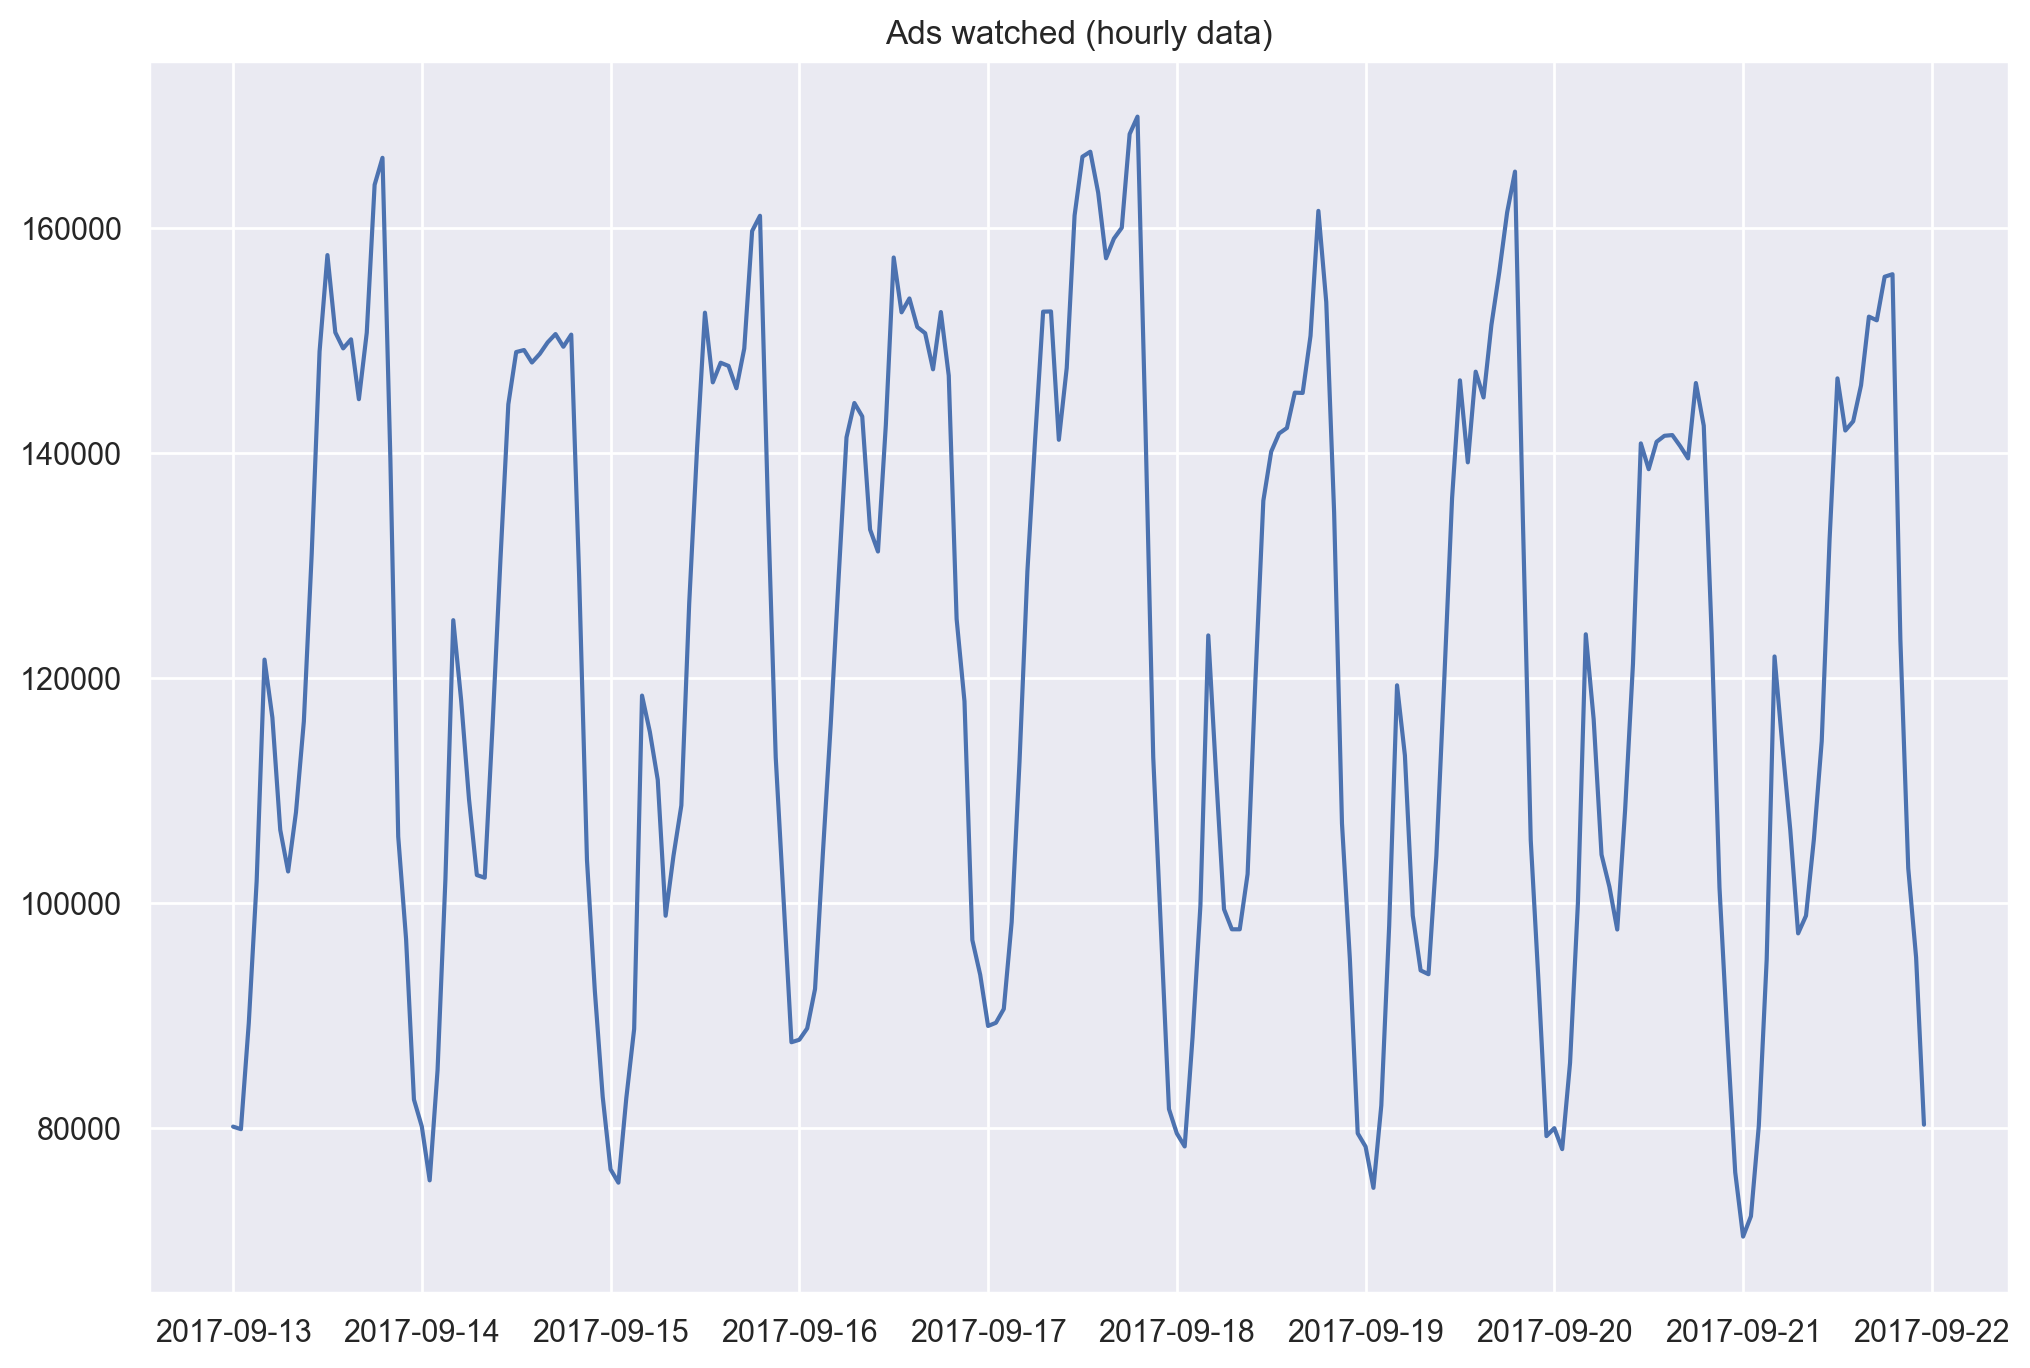

In [11]:
plt.figure(figsize=(12,8))
plt.plot(ads.Ads)
plt.title("Ads watched (hourly data)")
plt.grid(True)
plt.show()

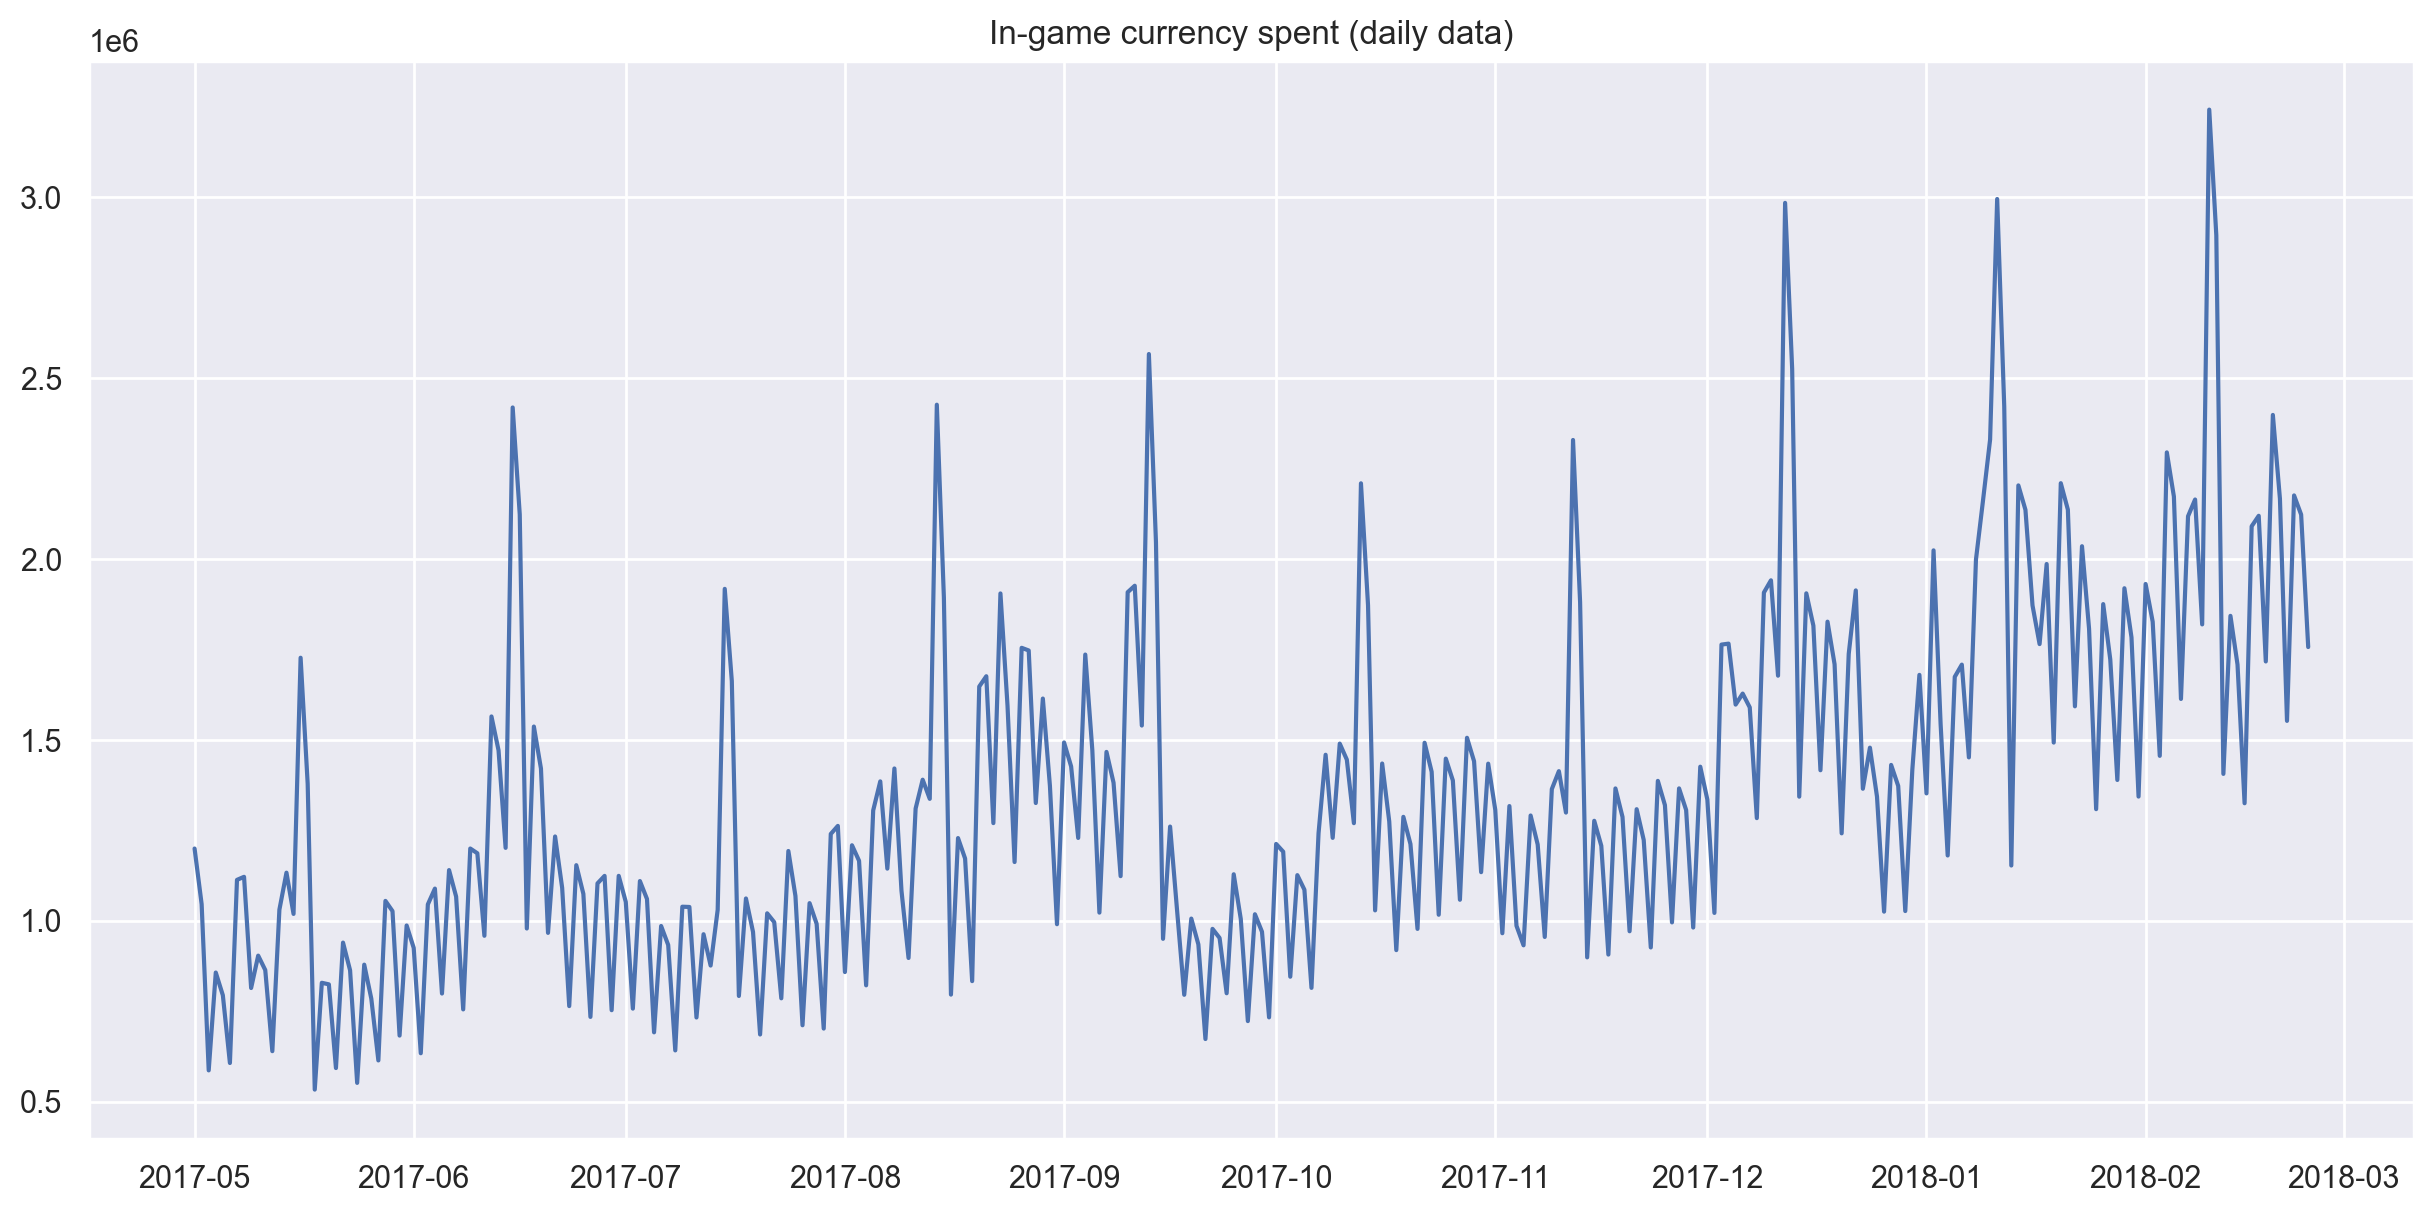

In [12]:
plt.figure(figsize=(15, 7))
plt.plot(currency.GEMS_GEMS_SPENT)
plt.title("In-game currency spent (daily data)")
plt.grid(True)
plt.show()

## Forecast quality metrics

In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / y_true) * 100

In [ ]:
# Importing everything

from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_squared_log_error, median_absolute_error,
                             r2_score)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


Now that we know how to measure the quality of the forecasts, let’s see what metrics we can use and how to translate the results for the boss. After that, one small detail remains - building the model.

## Move, smoothe, evaluate

Let’s start with a naive hypothesis: “tomorrow will be the same as today”. However, instead of a model like $$ \hat{y}_{t} = y_{t-1} $$ (which is actually a great baseline for any time series prediction problems and sometimes is impossible to beat), we will assume that the future value of our variable depends on the average of its k previous values. Therefore, we will use the moving average.

In [7]:
import numpy as np
a = [1,2,3,4,5,6,7,8]
a[-5:]
# np.average(a[-8])

[4, 5, 6, 7, 8]

In [ ]:
def moving_average(series, n):
    # calculate the average of the last n observations
    return np.average(series[-n:])

moving_average(ads, 24)  # prediction for the last observed day (past 24 hours)